# The k-means clustering algorithm

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eabarnes1010/course_objective_analysis/blob/main/code/kmeans_algorithm.ipynb)

*Elizabeth A. Barnes — BU Earth & Environment — Last updated: 2026-05-27*

## Learning objectives

- Walk through the two-step k-means iteration: **assign points to the nearest center**, then **move each center to the mean of its points**.
- Watch a 2-D toy example converge over a handful of iterations.
- See that the algorithm's final answer depends on the **initial guess** for the cluster centers.


## Setup

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# Figure defaults for this notebook.
mpl.rcParams["figure.dpi"] = 100
plt.rc("lines", linewidth=2.0)
plt.rc("font", size=14, weight="normal", family="sans-serif")

CLUSTER_COLORS = ["red", "limegreen", "blue"]
MS = 10  # marker size

## The two-step iteration

The algorithm is just two functions called in alternation:

1. `assign_clusters` — assign each point to its nearest center (Euclidean).
2. `update_centers` — replace each center with the mean of the points assigned to it.

We stop when the centers stop moving.

In [2]:
def assign_clusters(X, centers):
    """Return dict: cluster index -> list of points assigned to that cluster."""
    clusters = {i: [] for i in range(len(centers))}
    for x in X:
        distances = [np.linalg.norm(x - c) for c in centers]
        nearest = int(np.argmin(distances))
        clusters[nearest].append(x)
    return clusters


def update_centers(clusters):
    """Return the new center of each cluster (mean of its assigned points)."""
    return [np.mean(clusters[k], axis=0) for k in sorted(clusters)]


def kmeans_step(X, centers):
    """One full k-means iteration: assign, then update."""
    clusters = assign_clusters(X, centers)
    new_centers = update_centers(clusters)
    return new_centers, clusters

## Toy data and initial guess

12 points eyeballed off the [k-means Wikipedia example](https://en.wikipedia.org/wiki/K-means_clustering). We pick $k = 3$ and provide an explicit initial guess for the cluster centers so the example is reproducible.

In [3]:
X = np.array(
    [
        [0, 3],
        [0, 2],
        [0, 1],
        [2, -1],
        [1.9, -2],
        [3, -3],
        [4, -3],
        [5.1, -2],
        [5, -1],
        [7, 1],
        [7, 1.5],
        [7, 3.5],
    ]
)

initial_guess = [
    np.array([2.0, 5.0]),
    np.array([2.0, 0.0]),
    np.array([6.5, 0.0]),
]

## Watch it converge

We plot a 2x3 grid: the raw data + initial guess, then five rounds of the algorithm. Stars mark cluster centers (open stars = previous, filled stars = updated); dashed lines show how each center moved between iterations.


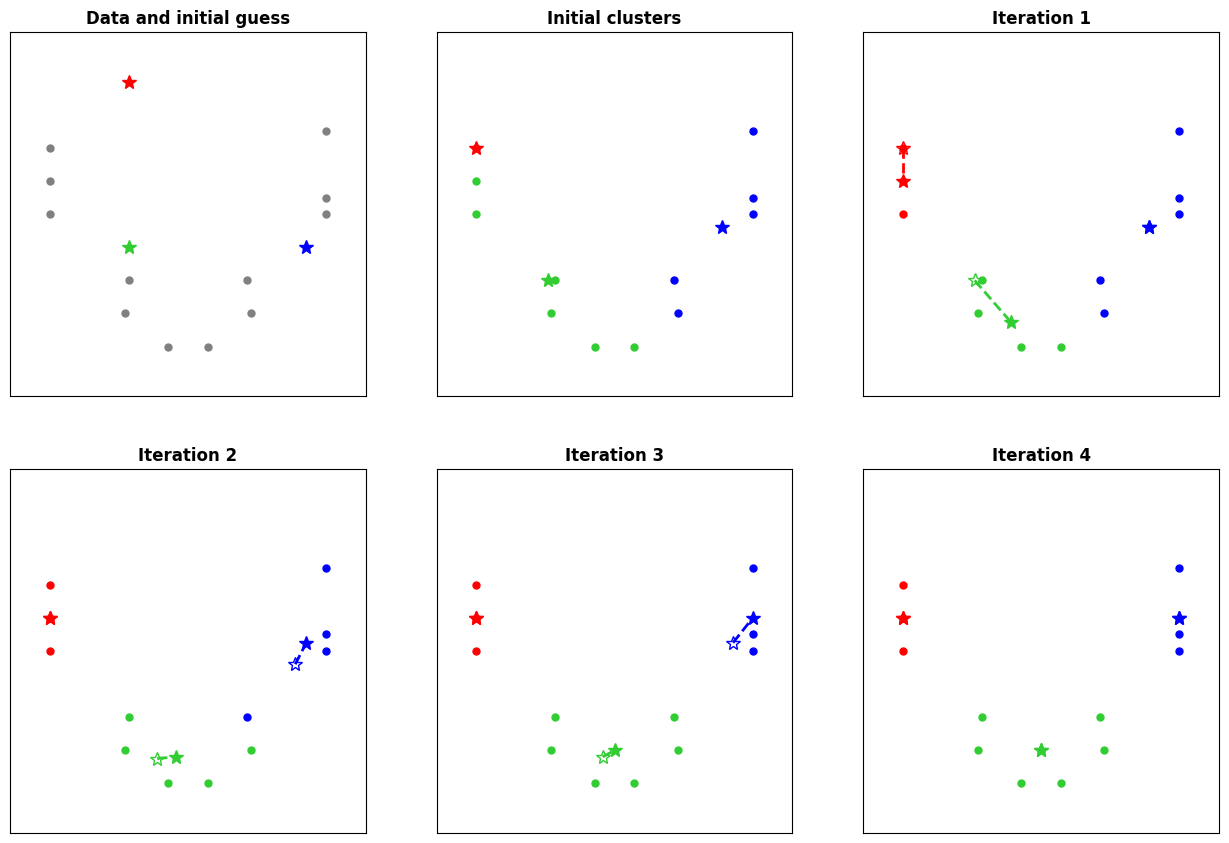

In [4]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12 * 1.3, 8 * 1.3))
ax = axes.flatten()

XLIM = (-1.0, 8.0)
YLIM = (-4.5, 6.5)

# --- Panel 0: raw data + initial guess.
ax[0].plot(X[:, 0], X[:, 1], ".", markeredgecolor="gray", color="gray", markersize=MS)
for i, c in enumerate(initial_guess):
    ax[0].plot(
        c[0],
        c[1],
        "*",
        color=CLUSTER_COLORS[i],
        markersize=MS,
        markeredgecolor=CLUSTER_COLORS[i],
    )
ax[0].set_title("Data and initial guess", fontsize=12, fontweight="bold")

# --- Panels 1-5: iterate.
centers = initial_guess
for j in range(5):
    old_centers = centers
    centers, clusters = kmeans_step(X, old_centers)

    panel = ax[j + 1]
    panel.set_title(
        "Initial clusters" if j == 0 else f"Iteration {j}",
        fontsize=12,
        fontweight="bold",
    )

    for i, new_c in enumerate(centers):
        pts = np.array(clusters[i])
        panel.plot(
            pts[:, 0],
            pts[:, 1],
            ".",
            markeredgecolor=CLUSTER_COLORS[i],
            color=CLUSTER_COLORS[i],
            markersize=MS,
        )
        # Filled star = current center.
        panel.plot(
            new_c[0],
            new_c[1],
            "*",
            color=CLUSTER_COLORS[i],
            markersize=MS,
            markeredgecolor=CLUSTER_COLORS[i],
        )
        # On follow-up iterations, also show the old center and the move.
        if j > 0:
            old_c = old_centers[i]
            panel.plot(
                old_c[0],
                old_c[1],
                "*",
                markeredgecolor=CLUSTER_COLORS[i],
                markersize=MS,
                color="none",
            )
            panel.plot(
                [old_c[0], new_c[0]],
                [old_c[1], new_c[1]],
                "--",
                color=CLUSTER_COLORS[i],
            )

# Common formatting for every panel.
for a in ax:
    a.set_xticks([])
    a.set_yticks([])
    a.set_xlim(XLIM)
    a.set_ylim(YLIM)

plt.show()

## Wrap-up

The three colored stars are the cluster centers. After the initial assignment, each iteration nudges each center toward the mean of its currently-assigned points; the dashed lines show that motion. After a few iterations the centers stop moving — that's convergence.

Two things to remember:

- **The algorithm converges to a *local* minimum** of within-cluster variance. Different initial guesses can converge to different answers.
- **You have to choose $k$ in advance.** Picking $k$ is its own problem (elbow plots, silhouette scores, domain knowledge).